In [14]:
# === Core Python ===
import os
import glob
import collections
import cftime
from datetime import datetime
from typing import Tuple, Dict, Optional

# === Numerical & Data Handling ===
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xcd
import xskillscore as xs
from xskillscore import rmse, pearson_r

# === Scientific Computation ===
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt, sosfilt, lfilter
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max
import metpy.calc as mpcalc  # Meteorology/thermodynamics

# === Plotting & Visualization ===
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# === Mapping & Cartography ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# === Visualization Helpers ===
import geocat.viz.util as gvutil
import geocat.viz as gv
import cmaps as gvcmaps  # Optional, check if available

from experiment_configs import get_experiment_dict
from ModelDataUtil import  ModelDataReader
from ObservationDataUtil import ObsDataReader


In [15]:
class TimeSeriesComparisonPlotter:
    """
    Plot time series from multiple experiments and a reference dataset.
    Supports ensemble visualization:
    - Mean line
    - Min/max shading
    - ±1σ whisker bars with horizontal caps (boxplot style)
    """
    def __init__(self, model_data: Dict[str, xr.DataArray], obs_data: Optional[xr.DataArray],
                 output_dir: str, var: Dict, units: Dict, region: str, regnam: str):
        self.model_data = model_data
        self.obs_data = obs_data
        self.output_dir = output_dir
        self.var = list(var.keys())[0]
        self.units = units[self.var]['unit']
        self.region = region
        self.regnam = regnam

    def _ensure_datetime64(self, da: xr.DataArray):
        """Convert cftime to datetime64 if needed."""
        if not isinstance(da.indexes['time'], pd.DatetimeIndex):
            da['time'] = da.indexes['time'].to_datetimeindex(time_unit='ns')  # suppress FutureWarning
        return da

    def _compute_metrics(self, model: xr.DataArray, obs: xr.DataArray):
        from sklearn.metrics import mean_squared_error
        from scipy.stats import pearsonr

        obs = obs.sel(time=model.time)

        ensemble_dim = next((d for d in model.dims if d != 'time'), None)
        rmse_list = []
        corr_list = []

        if ensemble_dim:
            for i in range(model.sizes[ensemble_dim]):
                member = model.isel({ensemble_dim: i})
                if np.all(np.isnan(member.values)):
                    continue
                rmse = np.sqrt(mean_squared_error(obs.values, member.values))
                corr, _ = pearsonr(obs.values, member.values)
                rmse_list.append(rmse)
                corr_list.append(corr)
            rmse_mean = np.mean(rmse_list)
            rmse_std = np.std(rmse_list)
            corr_mean = np.mean(corr_list)
            corr_std = np.std(corr_list)
        else:
            rmse_mean = np.sqrt(mean_squared_error(obs.values, model.values))
            corr_mean, _ = pearsonr(obs.values, model.values)
            rmse_std = 0
            corr_std = 0

        return rmse_mean, rmse_std, corr_mean, corr_std
    
    def plot(self, figsize=(12, 6), linewidth=2, alpha=0.3, 
             save=True, fontz=14, mean_metrics_on=False):
        plt.figure(figsize=figsize)
        sample_color = None
        legend_elements = []
        mean_metrics_on = False

        # Determine global reference time
        all_times = []
        for da in self.model_data.values():
            da = self._ensure_datetime64(da)
            all_times.append(da.time.values)
        if self.obs_data is not None:
            self.obs_data = self._ensure_datetime64(self.obs_data)
            all_times.append(self.obs_data.time.values)

        all_times_flat = np.concatenate(all_times)
        reference_time = pd.to_datetime(all_times_flat.min())
        ref_label = reference_time.strftime('%Y-%m-%d')

        def days_since(t):
            return (pd.to_datetime(t) - reference_time).days
        
        # Collect metrics strings to display in a text box
        metrics_text_lines = []

        for i, (exp_name, da) in enumerate(self.model_data.items()):
            da = self._ensure_datetime64(da)
            color = cm.tab10(i % 10)
            if sample_color is None:
                sample_color = color

            print(f"[INFO] {exp_name} dims: {da.dims}")

            ensemble_dim = next((dim for dim in ['ens', 'member'] if dim in da.dims), None)

            if ensemble_dim:
                if da.dims[0] != 'time':
                    da = da.transpose('time', ensemble_dim)
                time_days = np.array([days_since(t) for t in da.time.values])
                mean = da.mean(dim=ensemble_dim)
                std = da.std(dim=ensemble_dim)
                min_ = da.min(dim=ensemble_dim)
                max_ = da.max(dim=ensemble_dim)

                plt.plot(time_days, mean, label=None, color=color, linewidth=linewidth)
                plt.vlines(time_days, mean - std, mean + std, color=color, alpha=0.6, linewidth=1.5)

                if len(time_days) > 1:
                    delta = (time_days[1] - time_days[0]) * 0.25
                else:
                    delta = 1

                for t, m, s in zip(time_days, mean.values, std.values):
                    plt.hlines(m - s, t - delta, t + delta, color=color, linewidth=1)
                    plt.hlines(m + s, t - delta, t + delta, color=color, linewidth=1)

                plt.fill_between(time_days, min_, max_, color=color, alpha=0.15)
            else:
                other_dims = [d for d in da.dims if d != 'time']
                if other_dims:
                    print(f"[WARN] {exp_name} has extra dims {da.dims}; reducing to mean.")
                    da = da.mean(dim=other_dims, skipna=True)
                time_days = np.array([days_since(t) for t in da.time.values])
                plt.plot(time_days, da.values, label=None, color=color, linewidth=linewidth)

            # === Metric Computation ===
            if self.obs_data is not None and mean_metrics_on:
                obs = self._ensure_datetime64(self.obs_data).interp(time=da.time)
                rmse_vals = []
                corr_vals = []
                for mem in da[ensemble_dim].values:
                    member_ts = da.sel({ensemble_dim: mem})
                    rmse_val = rmse(member_ts, obs, dim='time', skipna=True)
                    corr_val = pearson_r(member_ts, obs, dim='time', skipna=True)
                    rmse_vals.append(rmse_val.values)
                    corr_vals.append(corr_val.values)
                rmse_mean = np.nanmean(rmse_vals)
                rmse_std = np.nanstd(rmse_vals)
                corr_mean = np.nanmean(corr_vals)
                corr_std = np.nanstd(corr_vals)
            
                metrics_text_lines.append(
                    f"{exp_name}:\n  RMSE = {rmse_mean:.2f} ± {rmse_std:.2f}\n  CORR = {corr_mean:.2f} ± {corr_std:.2f}"
                )
        
            legend_elements.append(Line2D([0], [0], color=color, lw=linewidth, label=exp_name))

        if self.obs_data is not None:
            time_days = np.array([days_since(t) for t in self.obs_data.time.values])
            plt.plot(time_days, self.obs_data.values, label=None, color='black', linestyle='--', linewidth=2, marker='o')
            legend_elements.append(Line2D([0], [0], color='black', linestyle='--', linewidth=2,
                                          marker='o', label='Observation'))

        legend_elements.append(Line2D(
            [0], [0], color='gray', lw=linewidth,
            marker='|', markersize=10, markeredgewidth=1.5,
            label='±1σ Whiskers + Mean'
        ))

        legend_elements.append(Patch(facecolor='gray', alpha=0.15, label='Min/Max Range'))

        # Add metrics text box
        if metrics_text_lines and mean_metrics_on:
            metrics_text = "\n\n".join(metrics_text_lines)
            plt.gcf().text(
                0.73, 0.25, metrics_text,
                fontsize=fontz - 2, va='top', ha='left',
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5')
            )
    
        # Labels and layout
        plt.title(f"{self.var} Time Series over {self.region}", fontsize=fontz + 2)
        plt.ylabel(f"{self.var} [{self.units}]", fontsize=fontz)
        plt.xlabel(f"Days since {ref_label}", fontsize=fontz)
        plt.xticks(fontsize=fontz - 2)
        plt.yticks(fontsize=fontz - 2)
        plt.grid(True, linewidth=0.6)
        plt.legend(
            handles=legend_elements,
            loc='best',
            fontsize=fontz - 2,
            frameon=True
        )
        #plt.legend(handles=legend_elements, loc='upper right', fontsize=fontz - 2)
        plt.tight_layout()
        plt.show()

        if save:
            os.makedirs(self.output_dir, exist_ok=True)
            fname = os.path.join(self.output_dir, f"timeseries_{self.var}_{self.regnam}.pdf")
            plt.savefig(fname, dpi=600)
            print(f"Saved plot to: {fname}")

        plt.close()



=== Processing region: global ===
Parsed time range: 2012-01-01 00:00:00 to 2012-02-01 23:59:59
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Parsed time range: 2012-01-01 00:00:00 to 2012-02-01 23:59:59
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 201

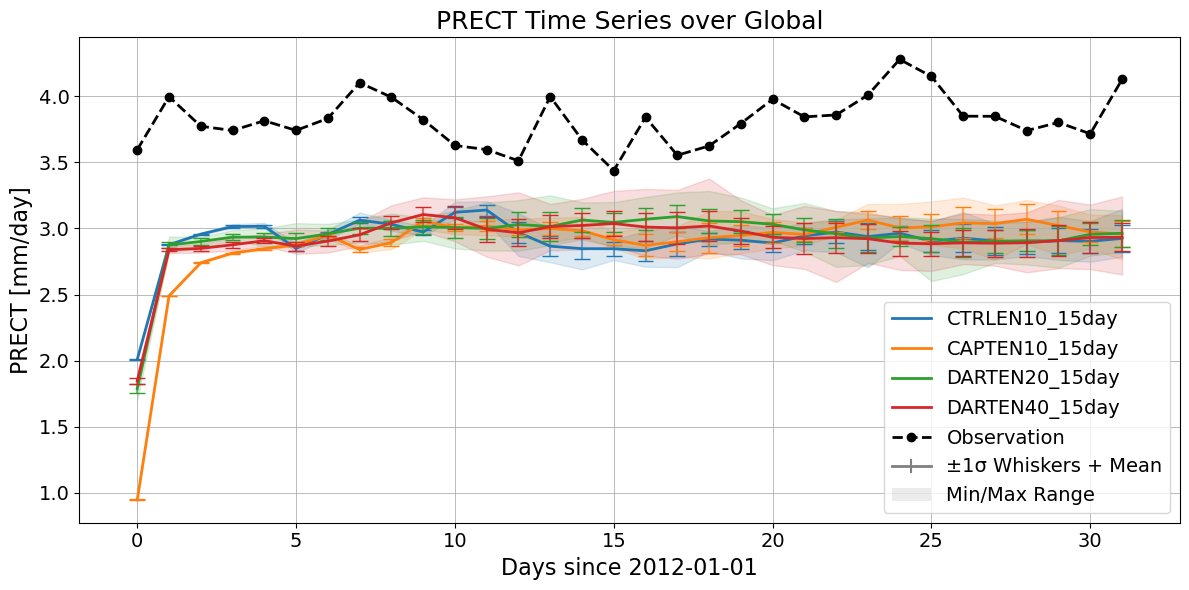

Saved plot to: /global/homes/z/zhan391/analysis/diagnostic/figures/timeseries_PRECT_global.pdf

=== Processing region: CONUS ===
Parsed time range: 2012-01-01 00:00:00 to 2012-02-01 23:59:59
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Parsed time range: 2012-01-01 00:00:00 to 2012-02-01 23:59:59
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range

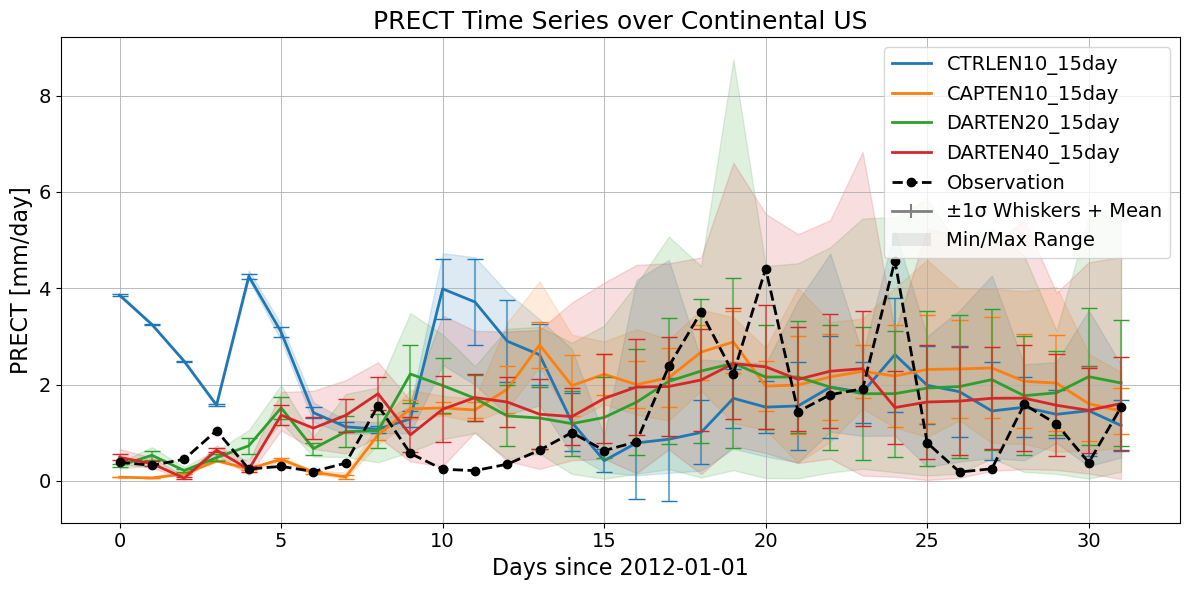

Saved plot to: /global/homes/z/zhan391/analysis/diagnostic/figures/timeseries_PRECT_CONUS.pdf

=== Processing region: NHMidLat ===
Parsed time range: 2012-01-01 00:00:00 to 2012-02-01 23:59:59
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Parsed time range: 2012-01-01 00:00:00 to 2012-02-01 23:59:59
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time ran

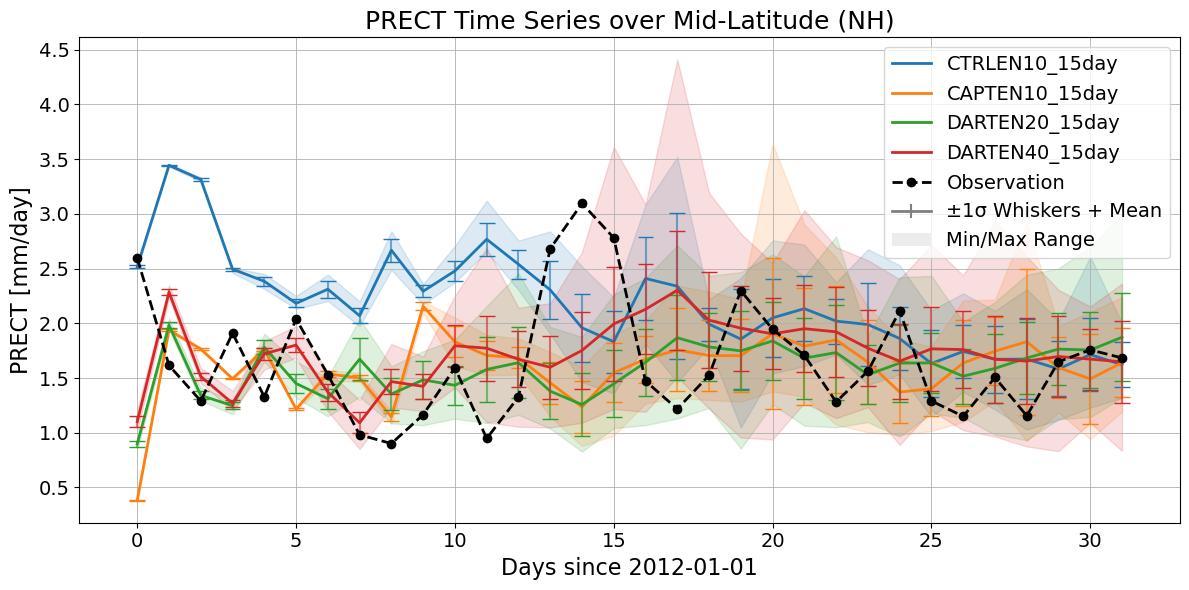

Saved plot to: /global/homes/z/zhan391/analysis/diagnostic/figures/timeseries_PRECT_NHMidLat.pdf

=== Processing region: Tropics ===
Parsed time range: 2012-01-01 00:00:00 to 2012-02-01 23:59:59
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Parsed time range: 2012-01-01 00:00:00 to 2012-02-01 23:59:59
Extracting time range: 2012-01-01 00:00:00 to 2012-02-01 00:00:00
Extracting time r

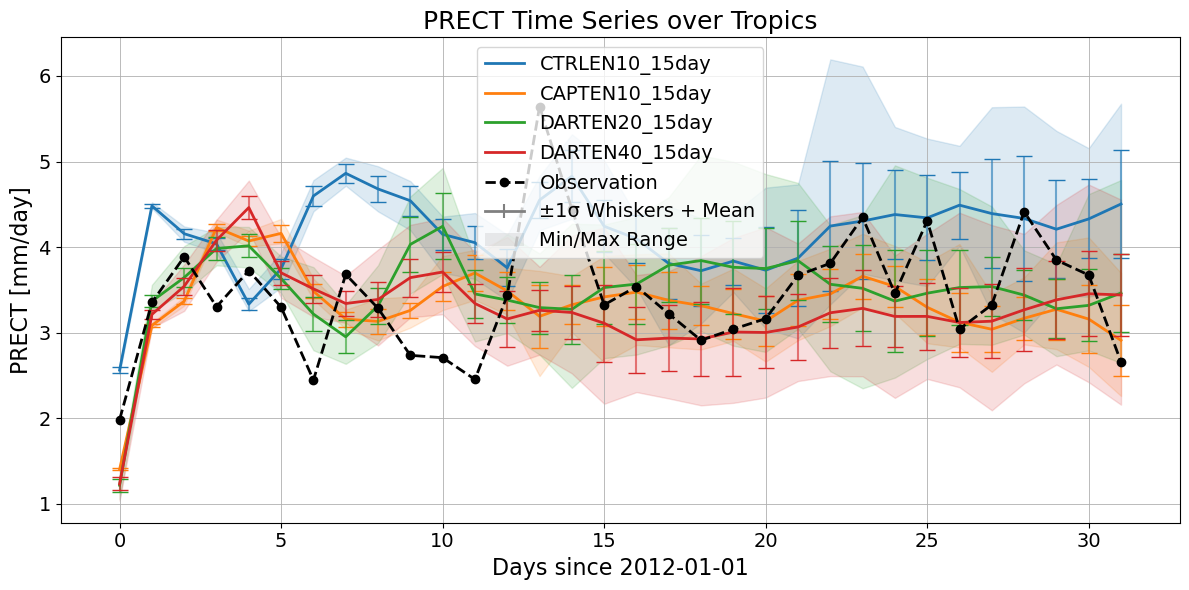

Saved plot to: /global/homes/z/zhan391/analysis/diagnostic/figures/timeseries_PRECT_Tropics.pdf


In [16]:
if __name__ == "__main__":
    top_path = "/pscratch/sd/z/zhan391/e3sm_dart"
    out_path = os.path.join(top_path, "diag_dart")
    summary_dir = os.path.join(out_path, "summary_metrics_netcdf")
    fig_path = "/global/homes/z/zhan391/analysis/diagnostic/figures"

    # === Setup ===
    compset = "F20TR"
    resolution = "ne30pg2_r05_IcoswISC30E3r5"
    machine = "compy"
    exp_base = f"{compset}_{resolution}_{machine}"

    ref_dataset = "IMERG"
    var_dict = {'PRECT': {'unit': 'mm/day', 'alias': 'PRECT', 'min': 0, "max": 12}}
    var = list(var_dict.keys())[0]
    frequency = "daily"

    model_list = ['CTRLEN10_15day', 'CAPTEN10_15day', 'DARTEN20_15day', 'DARTEN40_15day']

    # === Region aliases for figure titles ===
    regnam_dict = {
        "global": "Global",
        "CONUS": "Continental US",
        "NHMidLat": "Mid-Latitude (NH)",
        "Tropics": "Tropics"
    }

    for regnam, region_alias in regnam_dict.items():
        print(f"\n=== Processing region: {regnam} ===")

        # === Read model data ===
        reader = ModelDataReader(
            base_path=top_path,
            exp_base=exp_base,
            regnam=regnam,
            frequency=frequency,
            component="atm"
        )
        model_data = reader.read_variable_across_experiments(
            var, model_list, frequency=frequency, regional_mean=True
        )

        # === Determine common model time range ===
        start = max(pd.to_datetime(da.time.min().item()) for da in model_data.values())
        end = min(pd.to_datetime(da.time.max().item()) for da in model_data.values())
        freq_str = 'D' if frequency == 'daily' else '6H'
        common_time = pd.date_range(start=start, end=end, freq=freq_str)

        # === Align model data ===
        for exp in model_data:
            model_data[exp] = model_data[exp].sel(time=common_time)

        # === Define observation period using model-aligned time range ===
        period = f"{start.strftime('%Y%m')}-{end.strftime('%Y%m')}"
        print(f"[INFO] Observation period for alignment: {period}")

        # === Read observation data ===
        obs_reader = ObsDataReader(
            obsname=ref_dataset,
            period=period,
            frequency=frequency
        )
        obs_data = obs_reader.read(
            var=var,
            regnam=regnam,
            regional_mean=True
        )
        # Align obs to model time range
        obs_data = obs_data.sel(time=common_time)

        # === Plot ===
        plotter = TimeSeriesComparisonPlotter(
            model_data=model_data,
            obs_data=obs_data,
            output_dir=fig_path,
            var=var_dict,
            units=var_dict,
            regnam=regnam,
            region=region_alias
        )
        plotter.plot(
            fontz=16, 
            mean_metrics_on=True,
            save = True
        )
